In [1]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

In [126]:
DIR = Path("../../artifacts/2023-08-s10/experiments/accuracy-basis")

In [125]:
def load(dataset, logit_mod, arch, layer, basis_name, basis_mode, seeds=list(range(1, 5+1))):
    
    arr_dfs = []
    for seed in seeds:
        with open(DIR / f"{dataset}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"],
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_auroc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df

load(
    "cifar100-people--ts1.0", 
    "oneclass", 
    "cifar100-resnet18-p1",
    "layer3", 
    "pca", 
    basis_mode="centered",
    seeds=[1]
)

acc      seed original_acc  dims
      mean std count        first first
k                                      
1    0.180 NaN     1         0.55   256
2    0.208 NaN     1         0.55   256
3    0.246 NaN     1         0.55   256
4    0.224 NaN     1         0.55   256
5    0.264 NaN     1         0.55   256
6    0.284 NaN     1         0.55   256
7    0.272 NaN     1         0.55   256
8    0.270 NaN     1         0.55   256
9    0.262 NaN     1         0.55   256
10   0.270 NaN     1         0.55   256
11   0.272 NaN     1         0.55   256
12   0.310 NaN     1         0.55   256
13   0.342 NaN     1         0.55   256
14   0.338 NaN     1         0.55   256
15   0.364 NaN     1         0.55   256
16   0.382 NaN     1         0.55   256
17   0.412 NaN     1         0.55   256
18   0.418 NaN     1         0.55   256
19   0.422 NaN     1         0.55   256
20   0.428 NaN     1         0.55   256
32   0.474 NaN     1         0.55   256
64   0.532 NaN     1         0.55   256
128  0.566 NaN     1         0.55   256
256  0.550 NaN     1         0.55   256

===== mode=centered =====


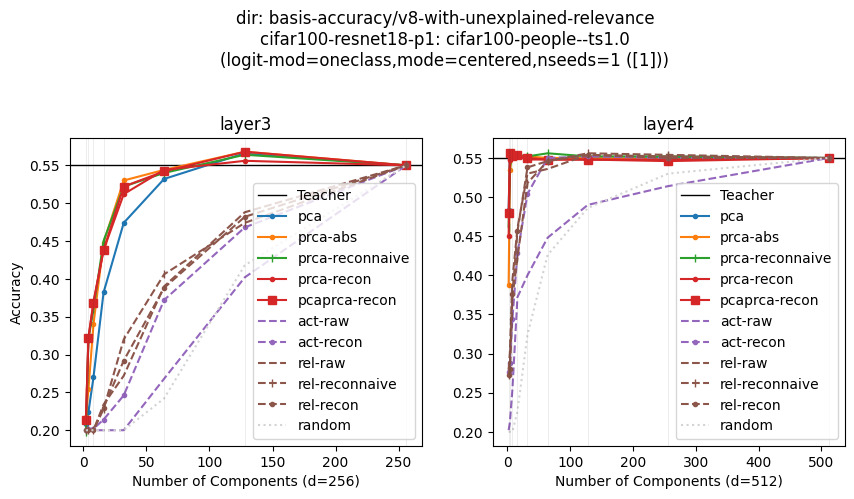

In [107]:
import numpy as np 

def color(name):
    if "random" in name:
        return "lightgray"
    elif name in ["rel-abs", "rel-recon", "rel-reconnaive"]  or name in ["act-recon", "act-abs"]:
        return plt.gca().lines[-1].get_color()
    else:
        return None

def marker(name):
    if name in ["pca", "prca-abs", "prca-recon", 'rel-recon', "act-recon"]:
        return "."
    elif "pcaprca" in name:
        return "s"
    elif name in ["rel-reconnaive", "prca-reconnaive"]:
        return "|"
    else:
        return None
    
def ls(name):
    if "rel" in name or "act" in name:
        return "--"
    elif "random" in name:
        return ":"
    else:
        return "-"
def viz(
    dataset, 
    training_size=1.0, 
    logit_mod="oneclass", basis_mode="centered", 
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs", 
        'pcaprca-abs',
        "rel", 
        "rel-abs",
        "random", 
        
    ],
    arch = "cifar100-resnet18-p1",
    seeds=[1],
    verbose=False
):
    
    dataset =  f"{dataset}--ts{training_size}"

    ncols = len(layers)
    plt.figure(figsize=(ncols * 5, 4))
    
    ii = 6
    
    print(f"===== mode={basis_mode} =====")
    for lix, layer in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        if lix == 0:
            plt.ylabel("Accuracy")
        for bix, basis_name in enumerate(basis_names):
            df = load(dataset, logit_mod, arch, layer, basis_name, basis_mode, seeds=seeds)
            d = df["dims"]["first"].values[-1]
            k = df.index
            max_k =  np.floor(np.log2(k.max()))
            power_of_two = np.power(2, np.arange(1, max_k+1))

            nseeds = df["seed"]["count"].values[-1]

            if bix == 0:
                teacher_metric = df["original_acc"]["first"].values[-1]

                plt.axhline(teacher_metric, ls='-', lw=1, color="k", label="Teacher")
            
            
            vcolor = color(basis_name)
            
            if "pcaprca" in basis_name:
                vcolor = plt.gca().lines[-1].get_color()
            
            stderr = df["acc"]["std"] / (nseeds ** 0.5)
            mean = df["acc"]["mean"]
            if verbose:
                print(f"[layer={layer}; {basis_name:20s}]: {np.around(mean.values[:10], decimals=4)}")
            
            selected = k.isin(power_of_two)
#             selected = [True] * k.shape[0]
            plt.plot(
                k[selected],
                mean[selected],
                label=f"{basis_name}(@k{k[ii]}={mean.values[ii]:.2f})" if verbose else basis_name,
                color=vcolor,
                ls=ls(basis_name),
                marker=marker(basis_name)
            )
            
            plt.fill_between(
                k[selected],
                (mean - stderr)[selected],
                (mean + stderr)[selected],
                alpha=0.5
            )
        
        for p in np.array(power_of_two):
                              
            plt.axvline(
                int(p), 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
        
        plt.xlabel(f"Number of Components (d={d})")

#         if lix == len(layers) - 1:
        plt.legend(
#             bbox_to_anchor=(1.0,1)
        )
            
    slug = "/".join(f"{DIR}".split("/")[-2:])
    plt.suptitle(f"dir: {slug}\n{arch}: {dataset}\n(logit-mod={logit_mod},mode={basis_mode},nseeds={nseeds} ({seeds}))", y=1.2)

viz(
    "cifar100-people",
    layers=["layer3", "layer4"],
    seeds=[1],
    basis_names=[
        "pca",
        "prca-abs",
        "prca-reconnaive",
        "prca-recon",
        "pcaprca-recon",
        
        'act-raw',
        'act-recon',
        'rel-raw',
        'rel-reconnaive',
        'rel-recon',
        "random",
    ]
)


# Unexplained Relevance

In [75]:
def load_unexplained_rel(dataset, arch, layer, basis_name, basis_mode="centered", logit_mod="oneclass", seeds=[1]):
    
    arr_dfs = []
    for seed in seeds:
        with open(DIR / f"{dataset}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
    return data["unexplained_relevance"]

load_unexplained_rel('cifar100-people--ts1.0', 'cifar100-resnet18-p1', 'layer3', 'pca')

[0.07011808454990387,
 0.03913538157939911,
 0.03250395134091377,
 0.029188508167862892,
 0.027502555400133133,
 0.02520432136952877,
 0.02305430732667446,
 0.022301189601421356,
 0.020803142338991165,
 0.02012483775615692,
 0.018972620368003845,
 0.017988745123147964,
 0.017288904637098312,
 0.016406621783971786,
 0.01567949168384075,
 0.013780474662780762,
 0.013108070939779282,
 0.012574796564877033,
 0.011986938305199146,
 0.011369118466973305,
 0.01095000933855772,
 0.010631216689944267,
 0.010151051916182041,
 0.009829621762037277,
 0.009401918388903141,
 0.009133448824286461,
 0.008963249623775482,
 0.008642306551337242,
 0.008242699317634106,
 0.007788663264364004,
 0.007594163063913584,
 0.007358584087342024,
 0.007123829331248999,
 0.006962710525840521,
 0.0066940984688699245,
 0.006606498267501593,
 0.006210641004145145,
 0.006036945153027773,
 0.005843523424118757,
 0.005669587291777134,
 0.00552030373364687,
 0.005400690715759993,
 0.005188044626265764,
 0.0050404109060764

===== mode=centered =====


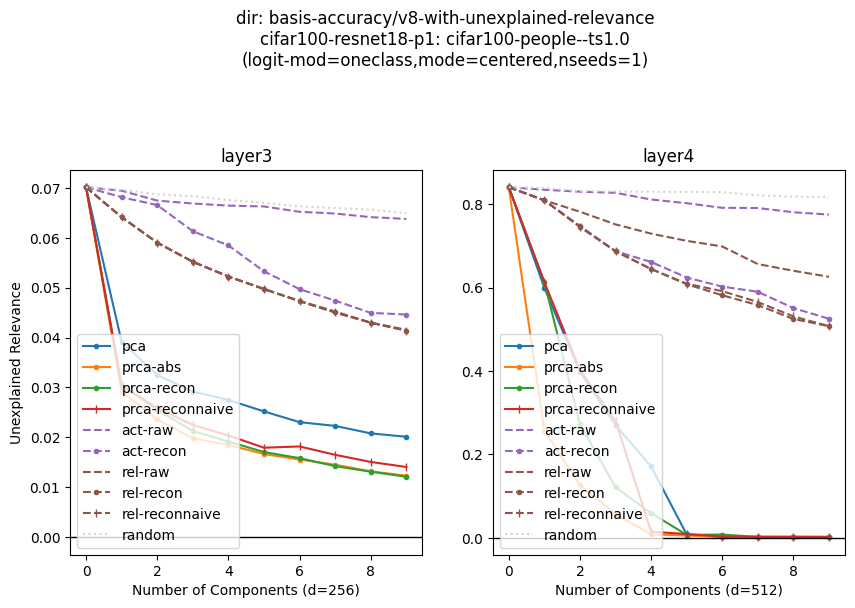

In [121]:
def viz_unexplained_rel(
    dataset, 
    training_size=1.0, 
    logit_mod="oneclass", basis_mode="centered", 
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs", 
        'pcaprca-abs',
        "rel", 
        "rel-abs",
        "random", 
        
    ],
    arch = "cifar100-resnet18-p1",
    seeds=[1],
    verbose=False
):
    
    dataset =  f"{dataset}--ts{training_size}"

    ncols = len(layers)
    plt.figure(figsize=(ncols * 5, 5))
        
#     def ls(basis_name):
#         if "naive" in basis_name:
#             return "--"
#         elif basis_name == "random":
#             return ":"
#         return None
#     def color(basis_name):
#         if "naive" in basis_name:
#             return plt.gca().lines[-1].get_color()
#         elif basis_name == "random":
#             return "lightgray"
    kk = 10
    print(f"===== mode={basis_mode} =====")
    for lix, layer in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        if lix == 0:
            plt.ylabel("Unexplained Relevance")
        for bix, basis_name in enumerate(basis_names):
            unexplained_rel = load_unexplained_rel(dataset, arch, layer, basis_name, seeds=seeds)
            plt.plot(unexplained_rel[:kk], label=basis_name, ls=ls(basis_name), marker=marker(basis_name), color=color(basis_name))
            
            d = len(unexplained_rel) - 1
        
        plt.xlabel(f"Number of Components (d={d})")
        plt.axhline(0, ls='-', lw=1, color="k")
        plt.legend()
            
    slug = "/".join(f"{DIR}".split("/")[-2:])
    plt.suptitle(f"dir: {slug}\n{arch}: {dataset}\n(logit-mod={logit_mod},mode={basis_mode},nseeds={len(seeds)})", y=1.2)

viz_unexplained_rel(
    "cifar100-people",
    layers=["layer3", "layer4"],
    seeds=[1],
    basis_names=[
        "pca",
        "prca-abs",
        "prca-recon",

        "prca-reconnaive",
        'act-raw',
        'act-recon',
        'rel-raw',
        'rel-recon',
        'rel-reconnaive',
        'random'
    ]
)